In [12]:
import marcrypto as mc
import numpy as np
import matplotlib.pylab as plt

In [13]:
rng = mc.random.rng_sv()

In [3]:
%timeit u = rng.next_u64()

297 ns ± 0.294 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


In [8]:
%timeit u = rng.next_f64()

298 ns ± 0.499 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


In [5]:
%timeit u = rng.next_f32()

317 ns ± 0.562 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


In [5]:
import numpy as np

In [6]:
%timeit x = np.random.randint(10)

1.3 µs ± 1.97 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


In [7]:
%timeit x = np.random.rand()

198 ns ± 0.219 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


In [21]:
for _ in range(10):
    print(rng.choice(['a', 'b', 'c'], [0.2, 0.3, 0.5]))

b
b
b
c
b
c
c
c
b
a


In [14]:
samples = np.array([rng.norm() for x in range(100000)])

In [15]:
np.mean(samples), np.std(samples)

(0.000310320694155244, 2.523029923293449)

(array([ 2065.,  4898.,  8911., 18048., 16183., 15747., 18093.,  9028.,
         4941.,  2086.]),
 array([-6.33734502e+00, -5.07065156e+00, -3.80395811e+00, -2.53726465e+00,
        -1.27057119e+00, -3.87773808e-03,  1.26281572e+00,  2.52950917e+00,
         3.79620263e+00,  5.06289609e+00,  6.32958954e+00]),
 <BarContainer object of 10 artists>)

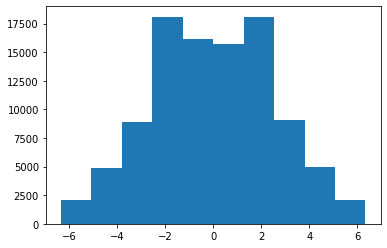

In [16]:
plt.hist(samples)

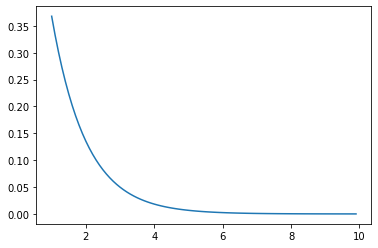

In [20]:
x = np.arange(1, 10, 0.1)
y = np.exp(-x)
plt.plot(x, y)

In [43]:
def make_probs_slot(step = 0.0001):
    intervals = np.arange(0, 20.0, step)
    probs = []
    for i in range(len(intervals)):
        p0 = np.exp(-i*step)
        p1 = np.exp(-(i+1)*step)
        p = p0 - p1
        probs.append(p)
    
    probs = np.array(probs)
    adjust_weight = 1.0/sum(probs)
    probs *= adjust_weight
    
    return intervals, probs

In [56]:
intervals, probs = make_probs_slot(step=0.01)
print(sum(probs))

0.9999999999999986


In [50]:
for i in range(10):
    print(f"{rng.choice_idx(probs)}")

651
34834
8763
1015
1771
5382
7616
1413
106
1443


In [59]:
%time sample_indices = [rng.choice_idx(probs) for _ in range(500000)]

CPU times: user 28.3 s, sys: 46.8 ms, total: 28.3 s
Wall time: 28.3 s


In [61]:
samples = intervals[sample_indices]

(array([9.455e+03, 8.485e+03, 8.491e+03, 6.230e+03, 6.360e+03, 6.422e+03,
        4.599e+03, 4.766e+03, 4.350e+03, 3.930e+03, 3.468e+03, 3.484e+03,
        2.532e+03, 2.688e+03, 2.340e+03, 2.071e+03, 2.069e+03, 1.639e+03,
        1.554e+03, 1.413e+03, 1.299e+03, 1.218e+03, 1.067e+03, 1.104e+03,
        7.750e+02, 8.170e+02, 7.300e+02, 6.470e+02, 6.520e+02, 4.440e+02,
        4.940e+02, 3.990e+02, 3.790e+02, 3.770e+02, 2.890e+02, 2.790e+02,
        2.460e+02, 2.400e+02, 2.120e+02, 1.680e+02, 1.810e+02, 1.290e+02,
        1.540e+02, 1.490e+02, 1.140e+02, 9.600e+01, 7.700e+01, 1.030e+02,
        6.400e+01, 6.000e+01, 5.800e+01, 6.100e+01, 5.400e+01, 4.100e+01,
        4.900e+01, 4.200e+01, 4.100e+01, 2.900e+01, 2.900e+01, 3.500e+01,
        2.600e+01, 2.200e+01, 2.300e+01, 1.900e+01, 2.100e+01, 1.400e+01,
        1.800e+01, 1.400e+01, 1.200e+01, 9.000e+00, 6.000e+00, 1.000e+00,
        1.200e+01, 6.000e+00, 7.000e+00, 2.000e+00, 3.000e+00, 7.000e+00,
        3.000e+00, 2.000e+00, 2.000e+0

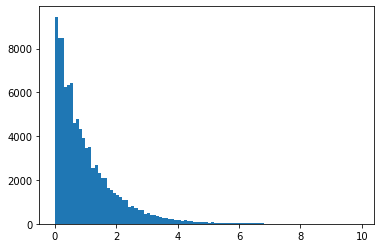

In [65]:
plt.hist(samples, bins=np.arange(0, 10, 0.1))